### Set Up

In [2]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind
from functools import reduce

In [3]:
scenarios_path = Path().resolve() / "../../scenarios_inputs" / "cheung_variants" 
annotated_output_path = Path().resolve() / "../../annotated_outputs" / "cheung_variants"
plots_path = Path().resolve() / "../../analysis" / "cheung_variants" / "cheung_visualizations"
print(f"scenarios_path: {scenarios_path}")
print(f"annotated_output_path: {annotated_output_path}")

filename_template = "%s_%d_choice_1.json"


scenarios_path: /Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/../../scenarios_inputs/cheung_variants
annotated_output_path: /Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants


In [4]:
import analysis_utils

### Select scenario to analyze

In [5]:
#get all of the json files in the annotated_output_path
scenario_name = "bird"
json_files = list(annotated_output_path.glob("*bird*choice_1.json"))

### Define Functions

In [6]:
#parse the read in filenames to get the condition and id
def parse_filename(filename):
    #filename is of the form "%s_%d_choice_1.json"
    parts = filename.stem.split("_")
    narrative = parts[0]
    id = int(parts[1])
    return narrative, id

In [7]:
def read_scenario(file_path): 

    narrative, id = parse_filename(file_path)


    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    nodes = [json.loads(line.strip()) for line in lines if line.strip()]


    # also return original scenario text for reference
    with open(scenarios_path / f"{narrative}.json") as f:
        scenario_list = json.load(f)
        #get the one with the matching id
        this_sceneraio = next(s for s in scenario_list if s['id'] == id)


         #extract the condition from the json read in
        scenario_text = this_sceneraio['text']
        scenario_deontology = this_sceneraio['deontology_level']
        scenario_utility = this_sceneraio['utility_level']
        
    #create a little dictionary with everything in it
    scenario_info = {
        "narrative": narrative,
        "id": id,
        "text": scenario_text,
        "deontology": scenario_deontology,
        "utility": scenario_utility
    }

    return nodes, scenario_info

In [8]:

def events_to_utility_df(nodes):
  
    util_dfs = []

    for node in nodes:
        n = node.get('node',{})
        if n.get('kind') == 'event':
            links = node.get('links')
            data = {}
            for link in links:
                to_node = link.get('to_node')
                value = link.get('link', {}).get('value')
                data[to_node] = value
                label = n.get('label')
                df = pd.DataFrame([data], index=[label])
            util_dfs.append(df)

    df = pd.concat(util_dfs, ignore_index=False)
    df = df.apply(pd.to_numeric)
    
    return df


In [9]:
def extract_deontology(nodes):
    
    value = None

    for node in nodes:
        n = node.get('node',{})
        if n.get('kind') == 'action_choice':
            # print(n.get('label'))
            links = node.get('links')
            # print(links)
            for link in links:
                    # print(link)
                    if link.get('link', {}).get('kind')=='v-link':
                        value = link.get('link', {}).get('value')
    

    return value

In [10]:
#attempt for a generitc utility function to read the annotation files for a given annotation output json file.
def parse_events_with_labels(file_path):
    """
    Parse a JSON file containing event nodes and extract their C/I/K polarity labels.
    
    Args:
        file_path: Path to the JSON file
        
    Returns:
        dict: Mapping of event labels to their C/I/K polarity strings
              e.g., {"Historical buildings are demolished": "C+I+K+", ...}
    """
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    # Parse each line to create a list of JSON objects
    nodes = [json.loads(line.strip()) for line in lines if line.strip()]
    
    # Find the first being node (first node with kind "being")
    being_node = None
    for node_obj in nodes:
        if node_obj.get('node', {}).get('kind') == 'being':
            being_node = node_obj
            break
    
    if not being_node:
        return {}
    
    # Create a mapping from event labels to their C/I/K values
    event_labels = {}
    
    for link in being_node.get('links', []):
        to_node_label = link.get('to_node')
        b_link_value = link.get('link', {}).get('value')
        
        if to_node_label and b_link_value:
            event_labels[to_node_label] = b_link_value
    
    # Filter to only include actual events
    event_nodes = {
        node_obj['node']['label'] 
        for node_obj in nodes 
        if node_obj.get('node', {}).get('kind') == 'event'
    }
    
    return {label: value for label, value in event_labels.items() if label in event_nodes}

In [11]:
def get_utilities(nodes):

    util_df =  events_to_utility_df(nodes)


    # For each being (column), calculate product of positive and negative utilities across outcomes
    utility_products = {}
    for col in util_df.columns:
        positive_utils = util_df[col][util_df[col] > 0]
        negative_utils = util_df[col][util_df[col] < 0]
        pos_product = reduce(lambda x, y: x * y, positive_utils, 1) if not positive_utils.empty else 0
        neg_product = reduce(lambda x, y: x * y, negative_utils, 1) if not negative_utils.empty else 0
        utility_products[col] = {"positive_product": pos_product, "negative_product": neg_product, "difference": pos_product - neg_product}

        util_mean_df = pd.DataFrame({'mean_utility': util_df.mean()})
    
    return util_mean_df


### Extract utility and deontology scores from individual scanerios to examine them closely

In [13]:
nodes, scenario_dictionary = read_scenario(json_files[4])
print(f"Scenario number: {scenario_dictionary['id']}")
print(f"Scenario utility: {scenario_dictionary['utility']}")
print(f"Scenario deontology: {scenario_dictionary['deontology']}")
util_df =  events_to_utility_df(nodes)
#get the column means for the utility dataframe
print(util_df.mean())
print(np.mean(util_df.mean()))

Scenario number: 4
Scenario utility: 2
Scenario deontology: 1
i                  -15.00
the injured bird    -6.25
dtype: float64
-10.625


In [14]:
nodes, scenario_dictionary = read_scenario(json_files[3])
print(f"Scenario number: {scenario_dictionary['id']}")
print(f"Scenario utility: {scenario_dictionary['utility']}")
print(f"Scenario deontology: {scenario_dictionary['deontology']}")
util_df =  events_to_utility_df(nodes)
#get the column means for the utility dataframe
print(util_df.mean())
print(np.mean(util_df.mean()))

Scenario number: 5
Scenario utility: 2
Scenario deontology: 2
i                  -32.5
the injured bird    -5.0
dtype: float64
-18.75


In [15]:
nodes, scenario_dictionary = read_scenario(json_files[1])
print(f"Scenario number: {scenario_dictionary['id']}")
print(f"Scenario utility: {scenario_dictionary['utility']}")
print(f"Scenario deontology: {scenario_dictionary['deontology']}")
util_df =  events_to_utility_df(nodes)
#get the column means for the utility dataframe
print(util_df.mean())
print(np.mean(util_df.mean()))

Scenario number: 6
Scenario utility: 2
Scenario deontology: 3
i                  -13.0
the injured bird    19.0
dtype: float64
3.0


In [16]:
nodes, scenario_dictionary = read_scenario(json_files[2])
print(f"Scenario number: {scenario_dictionary['id']}")
print(f"Scenario utility: {scenario_dictionary['utility']}")
print(f"Scenario deontology: {scenario_dictionary['deontology']}")
util_df =  events_to_utility_df(nodes)
#get the column means for the utility dataframe
print(util_df.mean())
print(np.mean(util_df.mean()))

Scenario number: 1
Scenario utility: 3
Scenario deontology: 1
i                  -36.0
the injured bird   -30.0
dtype: float64
-33.0


In [17]:
nodes, scenario_dictionary = read_scenario(json_files[0])
print(f"Scenario number: {scenario_dictionary['id']}")
print(f"Scenario utility: {scenario_dictionary['utility']}")
print(f"Scenario deontology: {scenario_dictionary['deontology']}")
util_df =  events_to_utility_df(nodes)
#get the column means for the utility dataframe
print(util_df.mean())
print(np.mean(util_df.mean()))

Scenario number: 2
Scenario utility: 3
Scenario deontology: 2
i                  -18.00
the injured bird    -6.25
dtype: float64
-12.125


In [18]:
nodes, scenario_dictionary = read_scenario(json_files[5])
print(f"Scenario number: {scenario_dictionary['id']}")
print(f"Scenario utility: {scenario_dictionary['utility']}")
print(f"Scenario deontology: {scenario_dictionary['deontology']}")
util_df =  events_to_utility_df(nodes)
#get the column means for the utility dataframe
print(util_df.mean())
print(np.mean(util_df.mean()))

Scenario number: 3
Scenario utility: 3
Scenario deontology: 3
i                                -1.0
1 bird                           13.0
1 animal care facility worker     9.0
dtype: float64
7.0


### get aggregate utilities and arrange into dataframe

In [19]:
rows = []

for file_path in json_files:
    
    nodes, scenario_dictionary = read_scenario(file_path)

    utility_rated = get_utilities(nodes)

    # utility_rated = utility_rated.drop(utility_rated.index[utility_rated.index == 'i'])
    util_mean = float(utility_rated.mean().iloc[0])

        # if hasattr(utility_rated, "item"):
        #     try:
        #         utility_rated = utility_rated.item()
        #     except Exception:
        #         pass

    rows.append(
        {
            "scenario_id": scenario_dictionary.get("id"),
            "narrative": scenario_dictionary.get("narrative"),
            "deontology_label": scenario_dictionary.get("deontology"),
            "utility_label": scenario_dictionary.get("utility"),
            "deontology_rating": extract_deontology(nodes),
            "utility_rating": util_mean,
        }
    )

results_df = pd.DataFrame(rows)
results_df.sort_values(by="scenario_id", inplace=True)
results_df

,scenario_id,narrative,deontology_label,utility_label,deontology_rating,utility_rating
2,1,bird,1,3,-71.0,-33.000
0,2,bird,2,3,-55.0,-12.125
5,3,bird,3,3,-49.0,7.000
4,4,bird,1,2,-71.0,-10.625
3,5,bird,2,2,-55.0,-18.750
1,6,bird,3,2,-49.0,3.000


In [20]:
# Ensure numeric columns are numeric
results_df["deontology_rating"] = pd.to_numeric(results_df["deontology_rating"], errors="coerce")
results_df["utility_rating"] = pd.to_numeric(results_df["utility_rating"], errors="coerce")

# 1) Means/SEs by deontology_label (for both dependent measures)
summary_by_deontology = (
    results_df
    .groupby("deontology_label", dropna=False)
    .agg(
        n=("deontology_rating", "count"),
        deontology_rating_mean=("deontology_rating", "mean"),
        deontology_rating_se=("deontology_rating", "sem"),
        utility_rating_mean=("utility_rating", "mean"),
        utility_rating_se=("utility_rating", "sem"),
    )
    .reset_index()
    .sort_values("deontology_label")
)

# 2) Means/SEs by utility_label (for both dependent measures)
summary_by_utility = (
    results_df
    .groupby("utility_label", dropna=False)
    .agg(
        n=("deontology_rating", "count"),
        deontology_rating_mean=("deontology_rating", "mean"),
        deontology_rating_se=("deontology_rating", "sem"),
        utility_rating_mean=("utility_rating", "mean"),
        utility_rating_se=("utility_rating", "sem"),
    )
    .reset_index()
    .sort_values("utility_label")
)


In [21]:
summary_by_deontology

,deontology_label,n,deontology_rating_mean,deontology_rating_se,utility_rating_mean,utility_rating_se
0,1,2,-71.0,0.0,-21.8125,11.1875
1,2,2,-55.0,0.0,-15.4375,3.3125
2,3,2,-49.0,0.0,5.0000,2.0000


In [22]:
summary_by_utility

,utility_label,n,deontology_rating_mean,deontology_rating_se,utility_rating_mean,utility_rating_se
0,2,3,-58.333333,6.565905,-8.791667,6.345246
1,3,3,-58.333333,6.565905,-12.708333,11.550688


In [17]:

# Long format for plotting both dependent measures together
plot_df = results_df.melt(
    id_vars=["deontology_label", "utility_label"],
    value_vars=["deontology_rating", "utility_rating"],
    var_name="measure",
    value_name="value",
)


In [18]:
plot_df

,deontology_label,utility_label,measure,value
0,1,3,deontology_rating,-85.000000
1,2,3,deontology_rating,-86.000000
2,3,3,deontology_rating,-37.000000
3,1,2,deontology_rating,-74.000000
4,2,2,deontology_rating,-86.000000
5,3,2,deontology_rating,-37.000000
6,1,1,deontology_rating,-74.000000
7,2,1,deontology_rating,-86.000000
8,3,1,deontology_rating,-37.000000
9,1,3,utility_rating,-20.250000


In [19]:
# Ensure label columns are ordered numerically for plotting
deontology_order = sorted(plot_df["deontology_label"].dropna().astype(int).unique())
utility_order = sorted(plot_df["utility_label"].dropna().astype(int).unique())

plot_df["deontology_label"] = pd.Categorical(
    plot_df["deontology_label"].astype(int),
    categories=deontology_order,
    ordered=True
)
plot_df["utility_label"] = pd.Categorical(
    plot_df["utility_label"].astype(int),
    categories=utility_order,
    ordered=True
)

# Re-run the plotting cell after this cell

/Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/analysis_utils.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_ylabel("Rating")
/Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/analysis_utils.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  


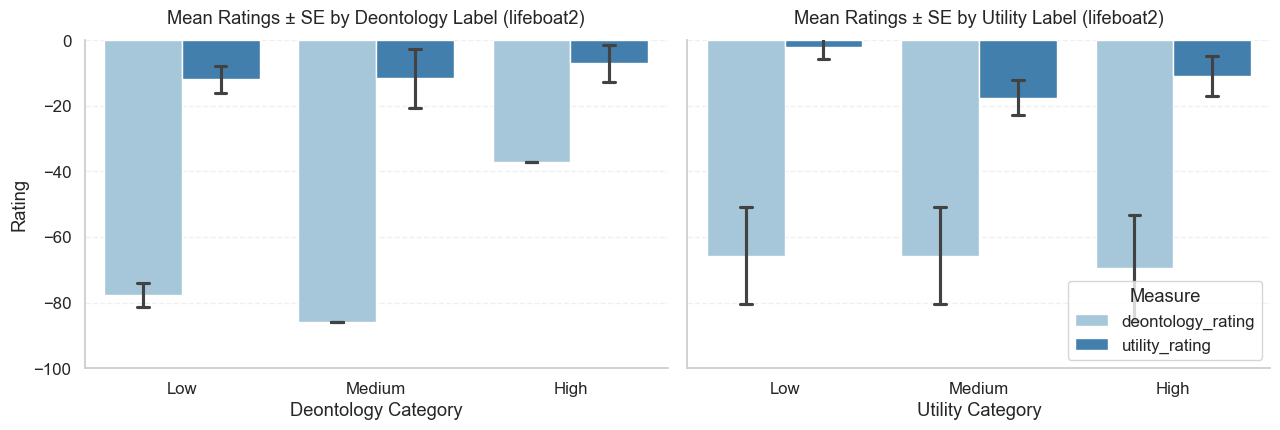

In [30]:
analysis_utils.make_deont_util_plot(scenario_name, plot_df, plots_path)